In [9]:
!pip install torchattacks -q
import os, time, tarfile, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEEDS        = [0, 42, 67]
EPOCHS       = 40
BATCH_SIZE   = 64
IMG_SIZE     = 160
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-5
NUM_WORKERS  = 2

FGSM_EPS    = [1, 2, 4, 8, 16]
PGD_EPS     = [1, 2, 4, 8, 16]
PGD_STEPS   = 10
PATCH_SIZES = [8, 16, 24, 32]
PATCH_STEPS = 50
PATCH_ALPHA = 4 / 255
PATCH_EVAL_SEED = 1234

AUTOATTACK_EPS = 8 / 255
AUTOATTACK_N   = 512
AUTOATTACK_BS  = 128

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

CKPT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Device: cuda
GPU: Tesla T4


In [4]:
def locate_imagewoof():
    work = Path("/kaggle/working/data") if Path("/kaggle/working").exists() else Path("./data")
    work.mkdir(parents=True, exist_ok=True)

    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise RuntimeError("Папка /kaggle/input не найдена -- добавьте датасет через Add Data.")

    for p in sorted(input_root.rglob("train")):
        if not p.is_dir():
            continue
        parent = p.parent
        for val_name in ("val", "validation", "test"):
            if (parent / val_name).is_dir():
                print("Найден готовый датасет:", parent, f"(train/{val_name})")
                return parent, val_name

    archive_exts = ("*.tgz", "*.tar.gz", "*.zip")
    archives = [p for ext in archive_exts for p in input_root.rglob(ext)]
    for p in archives:
        print("Распаковываю", p)
        if p.suffix == ".zip":
            import zipfile
            with zipfile.ZipFile(p) as z:
                z.extractall(work)
        else:
            with tarfile.open(p) as tar:
                tar.extractall(work)
        for root, dirs, files in os.walk(work):
            dirs_lower = [d.lower() for d in dirs]
            if "train" in dirs_lower:
                root_path = Path(root)
                for val_name in ("val", "validation", "test"):
                    if val_name in dirs_lower:
                        real_val = dirs[dirs_lower.index(val_name)]
                        return root_path, real_val

    raise RuntimeError("Не нашёл train/ + val ни в /kaggle/input, ни после распаковки архивов.")

DATA_ROOT, VAL_DIRNAME = locate_imagewoof()

WNID_TO_BREED = {
    "n02086240": "Shih-Tzu",
    "n02087394": "Rhodesian ridgeback",
    "n02088364": "Beagle",
    "n02089973": "English foxhound",
    "n02093754": "Border terrier",
    "n02096294": "Australian terrier",
    "n02099601": "Golden retriever",
    "n02105641": "Old English sheepdog",
    "n02111889": "Samoyed",
    "n02115641": "Dingo",
}

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])

train_set = torchvision.datasets.ImageFolder(DATA_ROOT / "train", transform=train_tf)
val_set   = torchvision.datasets.ImageFolder(DATA_ROOT / VAL_DIRNAME, transform=eval_tf)

if train_set.classes != val_set.classes:
    raise RuntimeError("классы в train и val не совпадают")
CLASSES = train_set.classes
BREEDS  = [WNID_TO_BREED.get(c, c) for c in CLASSES]

val_loader = DataLoader(val_set, batch_size=128, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f"train {len(train_set)} | val {len(val_set)} | классов {len(CLASSES)}")

Распаковываю /kaggle/input/datasets/ulianaandrosova/imagewoolf/imagewoof2-320.tgz


/tmp/ipykernel_58/4042696838.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(work)


train 9025 | val 3929 | классов 10


In [5]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class ResNetImageWoof(nn.Module):
    def __init__(self, num_classes, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        super().__init__()
        self.normalize = Normalize(mean, std)
        backbone = torchvision.models.resnet18(weights=None)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(self.normalize(x))


def build_model(seed):
    set_seed(seed)
    return ResNetImageWoof(num_classes=len(CLASSES)).to(DEVICE)

In [6]:
def fgsm(net, x, y, eps):
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(net(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    x_adv = x + eps * grad.sign()
    return x_adv.clamp(0, 1).detach()


def pgd(net, x, y, eps, alpha, steps):
    x_orig = x.clone().detach()
    x_adv = (x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(net(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        delta = (x_adv - x_orig).clamp(-eps, eps)
        x_adv = (x_orig + delta).clamp(0, 1).detach()
    return x_adv


def make_patch_mask(shape, patch_size, device):
    B, C, H, W = shape
    mask = torch.zeros(B, 1, H, W, device=device)
    tops  = torch.randint(0, H - patch_size + 1, (B,))
    lefts = torch.randint(0, W - patch_size + 1, (B,))
    for i in range(B):
        mask[i, :, tops[i]:tops[i] + patch_size, lefts[i]:lefts[i] + patch_size] = 1.0
    return mask


def patch_attack(net, x, y, patch_size, steps, alpha):
    mask = make_patch_mask(x.shape, patch_size, x.device)
    x_adv = (x.clone().detach() * (1 - mask) + torch.rand_like(x) * mask).clamp(0, 1).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(net(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = (x_adv.detach() + alpha * grad.sign() * mask).clamp(0, 1).detach()
    return x_adv


@torch.no_grad()
def clean_accuracy(net, loader):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (net(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


def attack_accuracy(net, loader, attack_fn):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = attack_fn(net, x, y)
        with torch.no_grad():
            correct += (net(x_adv).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

In [7]:
def train_seed(seed):
    set_seed(seed)
    model = ResNetImageWoof(num_classes=len(CLASSES)).to(DEVICE)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM,
                                weight_decay=WEIGHT_DECAY, nesterov=True)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader))
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    ckpt_path = str(CKPT_DIR / f"resnet18_imagewoof_seed{seed}.pt")
    best_val = 0.0
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        va = clean_accuracy(model, val_loader)
        if va > best_val:
            best_val = va
            torch.save({"epoch": epoch, "state_dict": model.state_dict(),
                        "classes": CLASSES, "img_size": IMG_SIZE, "val_acc": va, "seed": seed}, ckpt_path)

    print(f"seed {seed}: best val {best_val*100:.2f}% | {(time.time()-t0)/60:.1f} мин | {ckpt_path}")
    return ckpt_path


ckpts = {}
for s in SEEDS:
    ckpts[s] = train_seed(s)

/tmp/ipykernel_58/4130191547.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_58/4130191547.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


seed 0: best val 79.66% | 15.0 мин | /kaggle/working/resnet18_imagewoof_seed0.pt
seed 42: best val 79.71% | 15.0 мин | /kaggle/working/resnet18_imagewoof_seed42.pt
seed 67: best val 80.07% | 15.0 мин | /kaggle/working/resnet18_imagewoof_seed67.pt


In [10]:
results = {
    "clean": {},
    "fgsm": {e: {} for e in FGSM_EPS},
    "pgd":  {e: {} for e in PGD_EPS},
    "patch": {p: {} for p in PATCH_SIZES},
}

for s in SEEDS:
    model = ResNetImageWoof(num_classes=len(CLASSES)).to(DEVICE)
    ckpt = torch.load(ckpts[s], map_location=DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    results["clean"][s] = clean_accuracy(model, val_loader)

    for e in FGSM_EPS:
        eps = e / 255
        results["fgsm"][e][s] = attack_accuracy(
            model, val_loader, lambda n, x, y, eps=eps: fgsm(n, x, y, eps))

    for e in PGD_EPS:
        eps = e / 255
        results["pgd"][e][s] = attack_accuracy(
            model, val_loader, lambda n, x, y, eps=eps: pgd(n, x, y, eps, eps / 4, PGD_STEPS))

    for p in PATCH_SIZES:
        torch.manual_seed(PATCH_EVAL_SEED)
        results["patch"][p][s] = attack_accuracy(
            model, val_loader, lambda n, x, y, p=p: patch_attack(n, x, y, p, PATCH_STEPS, PATCH_ALPHA))

    print(f"seed {s}: оценка на полном val завершена (clean {results['clean'][s]*100:.2f}%)")

seed 0: оценка на полном val завершена (clean 79.66%)
seed 42: оценка на полном val завершена (clean 79.71%)
seed 67: оценка на полном val завершена (clean 80.07%)


In [11]:
def mean_std(seed_dict):
    vals = np.array([seed_dict[s] for s in SEEDS]) * 100
    return vals.mean(), vals.std()

clean_m, clean_s = mean_std(results["clean"])
print(f"Сидов: {SEEDS} | полный val ({len(val_set)} картинок)\n")
print(f"Clean accuracy: {clean_m:5.2f}% ± {clean_s:.2f}\n")

print("FGSM (полный val):")
fgsm_m, fgsm_s = [], []
for e in FGSM_EPS:
    m, sd = mean_std(results["fgsm"][e])
    fgsm_m.append(m); fgsm_s.append(sd)
    print(f"  eps = {e:2d}/255 -> {m:5.2f}% ± {sd:.2f}")

print("\nPGD-10 (полный val):")
pgd_m, pgd_s = [], []
for e in PGD_EPS:
    m, sd = mean_std(results["pgd"][e])
    pgd_m.append(m); pgd_s.append(sd)
    print(f"  eps = {e:2d}/255 -> {m:5.2f}% ± {sd:.2f}")

print("\nPatch (полный val):")
patch_m, patch_s = [], []
for p in PATCH_SIZES:
    m, sd = mean_std(results["patch"][p])
    patch_m.append(m); patch_s.append(sd)
    area = p * p / (IMG_SIZE ** 2) * 100
    print(f"  patch {p:2d}x{p:<2d} ({area:4.1f}%) -> {m:5.2f}% ± {sd:.2f}")

Сидов: [0, 42, 67] | полный val (3929 картинок)

Clean accuracy: 79.82% ± 0.18

FGSM (полный val):
  eps =  1/255 -> 41.05% ± 0.44
  eps =  2/255 -> 26.87% ± 0.59
  eps =  4/255 -> 18.38% ± 0.28
  eps =  8/255 -> 13.83% ± 0.09
  eps = 16/255 -> 10.57% ± 0.22

PGD-10 (полный val):
  eps =  1/255 -> 30.13% ± 0.96
  eps =  2/255 ->  8.76% ± 0.24
  eps =  4/255 ->  1.28% ± 0.06
  eps =  8/255 ->  0.18% ± 0.14
  eps = 16/255 ->  0.08% ± 0.05

Patch (полный val):
  patch  8x8  ( 0.2%) -> 68.62% ± 0.55
  patch 16x16 ( 1.0%) -> 48.65% ± 0.39
  patch 24x24 ( 2.2%) -> 27.60% ± 0.55
  patch 32x32 ( 4.0%) -> 14.60% ± 0.42


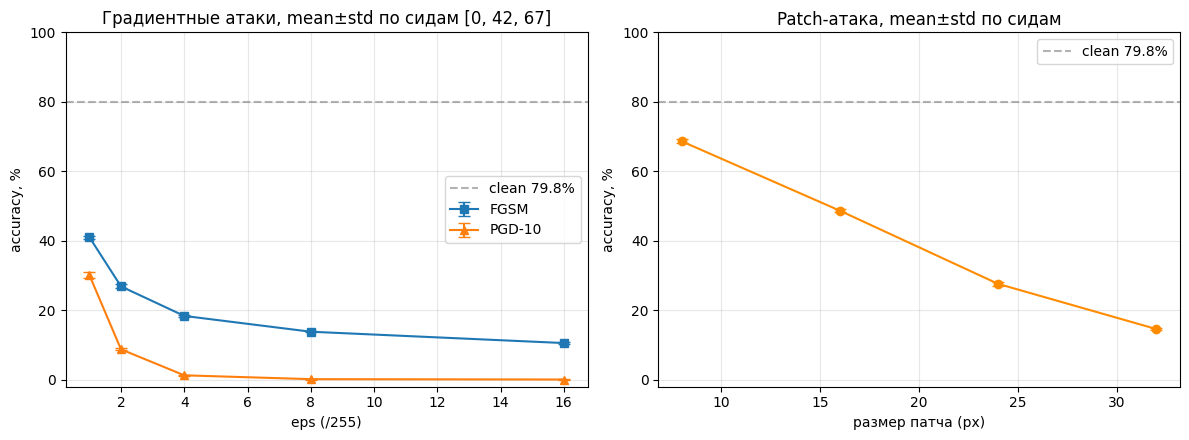

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].errorbar(FGSM_EPS, fgsm_m, yerr=fgsm_s, marker="s", capsize=4, label="FGSM")
ax[0].errorbar(PGD_EPS, pgd_m, yerr=pgd_s, marker="^", capsize=4, label="PGD-10")
ax[0].axhline(clean_m, ls="--", color="gray", alpha=0.6, label=f"clean {clean_m:.1f}%")
ax[0].set_xlabel("eps (/255)"); ax[0].set_ylabel("accuracy, %")
ax[0].set_title(f"Градиентные атаки, mean±std по сидам {SEEDS}")
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_ylim(-2, 100)

ax[1].errorbar(PATCH_SIZES, patch_m, yerr=patch_s, marker="o", capsize=4, color="darkorange")
ax[1].axhline(clean_m, ls="--", color="gray", alpha=0.6, label=f"clean {clean_m:.1f}%")
ax[1].set_xlabel("размер патча (px)"); ax[1].set_ylabel("accuracy, %")
ax[1].set_title("Patch-атака, mean±std по сидам")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_ylim(-2, 100)

plt.tight_layout(); plt.show()